# 2d plots

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import os

import sys
sys.path.append("..")

from sources.simulation import *
from sources.plotting import *
from sources.analysis import *
from sources.models import *
from sources.data_storage import *

## box domain

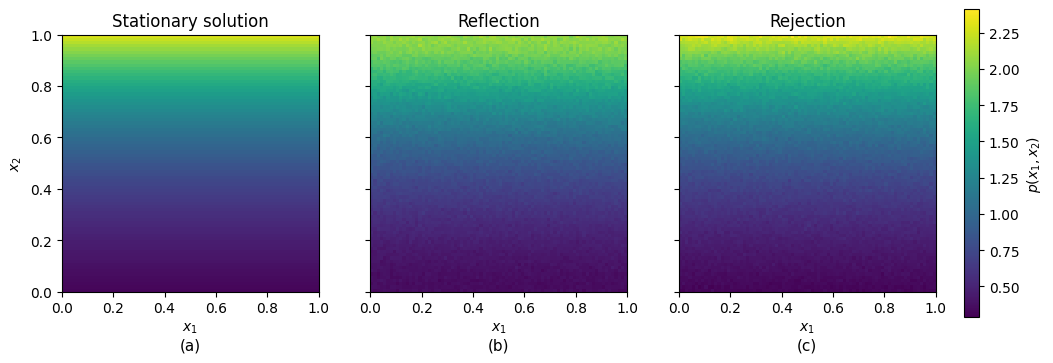

In [2]:
# Rectangular-domain validation
# Stationary solution, reflection and rejection

bounds = ((0, 1), (0, 1))
b = np.array([0.0, 1.0])
sigma = np.eye(2)

dt = 0.01
bins = 80

problem_path = "./data/rectangle_b-0-1_s-I"
boundary_types = ["reflection", "rejection"]

cmap = plt.get_cmap()


# Common Cartesian grid
x_edges = np.linspace(bounds[0][0], bounds[0][1], bins + 1)
y_edges = np.linspace(bounds[1][0], bounds[1][1], bins + 1)

x_centres = 0.5 * (x_edges[:-1] + x_edges[1:])
y_centres = 0.5 * (y_edges[:-1] + y_edges[1:])

x_mesh, y_mesh = np.meshgrid(
    x_centres,
    y_centres,
    indexing="ij"
)


# Stationary solution
p_exact = stationary_solution_2d(
    x_mesh,
    y_mesh,
    b,
    sigma,
    bounds
)

density_data = {"exact": p_exact}
p_scales = [p_exact]


# Numerical densities
for boundary_type in boundary_types:

    X = load_solution(
        f"{boundary_type}_dt-{dt}.npy",
        problem_path
    )

    p_num, _, _ = np.histogram2d(
        X[:, 0],
        X[:, 1],
        bins=[x_edges, y_edges],
        density=True
    )

    density_data[boundary_type] = p_num
    p_scales.append(p_num)


# Shared colour scale
colorbar_values = get_colorbar_values_2d(p_scales)


# Plot
fig, ax = plt.subplots(
    1, 3,
    figsize=(12, 4),
    sharex=True,
    sharey=True
)

titles = {
    "exact": "Stationary solution",
    "reflection": "Reflection",
    "rejection": "Rejection"
}

plot_density_2d(
    density_data["exact"],
    bounds,
    ax=ax[0],
    title=titles["exact"],
    colorbar_values=colorbar_values,
    cmap=cmap
)

for i, boundary_type in enumerate(boundary_types):

    plot_density_2d(
        density_data[boundary_type],
        bounds,
        ax=ax[i + 1],
        title=titles[boundary_type],
        colorbar_values=colorbar_values,
        cmap=cmap
    )


# Consistent labels and formatting
for a in ax:
    a.set_xlabel(r"$x_1$")
    a.set_ylabel("")
    a.set_aspect("equal")

ax[0].set_ylabel(r"$x_2$")


# Shared colourbar using your existing function
add_shared_colorbar(
    fig,
    ax,
    colorbar_values,
    cmap=cmap,
    label=r"$p(x_1,x_2)$"
)

# Add panel labels below each subplot
panel_labels = [r"(a)", r"(b)", r"(c)"]

for i, label in enumerate(panel_labels):
    ax[i].text(
        0.5, -0.18, label,
        transform=ax[i].transAxes,
        ha="center",
        va="top",
        fontsize=11
    )


plt.show()

## Disk

### isotropic case

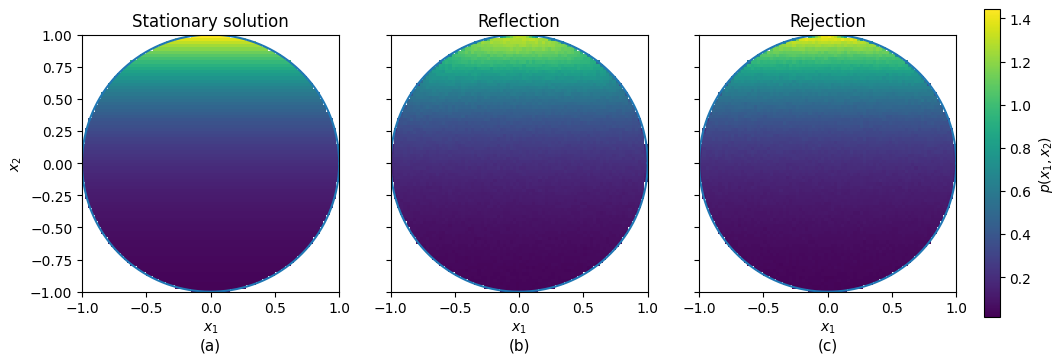

In [3]:
# Isotropic diffusion in the unit disk
# Stationary solution, reflection and rejection

radius = 1.0
dt = 0.01
bins = 80

b = np.array([0.0, 1.0])
sigma = np.eye(2)

problem_path = "./data/disk_b-0-1_s-I"
boundary_types = ["reflection", "rejection"]

cmap = plt.get_cmap()


# Build the Cartesian grid used for the reference density
x_edges = np.linspace(-radius, radius, bins + 1)
y_edges = np.linspace(-radius, radius, bins + 1)

x_centres = 0.5 * (x_edges[:-1] + x_edges[1:])
y_centres = 0.5 * (y_edges[:-1] + y_edges[1:])

x_mesh, y_mesh = np.meshgrid(
    x_centres,
    y_centres,
    indexing="ij"
)


# Stationary reference solution
p_exact = stationary_solution_disk(
    x_mesh,
    y_mesh,
    b,
    sigma,
    radius=radius
)

density_data = {"exact": p_exact}
p_scales = [p_exact]


# Load precomputed numerical solutions
for boundary_type in boundary_types:

    X = load_solution(
        f"{boundary_type}_dt-{dt}.npy",
        problem_path
    )

    p_num, _, _ = histogram_density_disk(
        X,
        radius=radius,
        bins=bins
    )

    density_data[boundary_type] = p_num
    p_scales.append(p_num)


# Shared colour scale
colorbar_values = get_colorbar_values_2d(p_scales)


# Plot
fig, ax = plt.subplots(
    1, 3,
    figsize=(12, 4),
    sharex=True,
    sharey=True
)

plot_density_disk(
    density_data["exact"],
    x_edges,
    y_edges,
    radius=radius,
    ax=ax[0],
    title="Stationary solution",
    colorbar_values=colorbar_values,
    cmap=cmap
)

plot_density_disk(
    density_data["reflection"],
    x_edges,
    y_edges,
    radius=radius,
    ax=ax[1],
    title="Reflection",
    colorbar_values=colorbar_values,
    cmap=cmap
)

plot_density_disk(
    density_data["rejection"],
    x_edges,
    y_edges,
    radius=radius,
    ax=ax[2],
    title="Rejection",
    colorbar_values=colorbar_values,
    cmap=cmap
)


# Consistent axis labels
for a in ax:
    a.set_xlabel(r"$x_1$")
    a.set_ylabel("")
    a.set_aspect("equal")

ax[0].set_ylabel(r"$x_2$")


# One shared colourbar
add_shared_colorbar(
    fig,
    ax,
    colorbar_values,
    cmap=cmap,
    label=r"$p(x_1,x_2)$"
)

# Add panel labels below each subplot
panel_labels = [r"(a)", r"(b)", r"(c)"]

for i, label in enumerate(panel_labels):
    ax[i].text(
        0.5, -0.18, label,
        transform=ax[i].transAxes,
        ha="center",
        va="top",
        fontsize=11
    )


plt.show()

### anisotropic

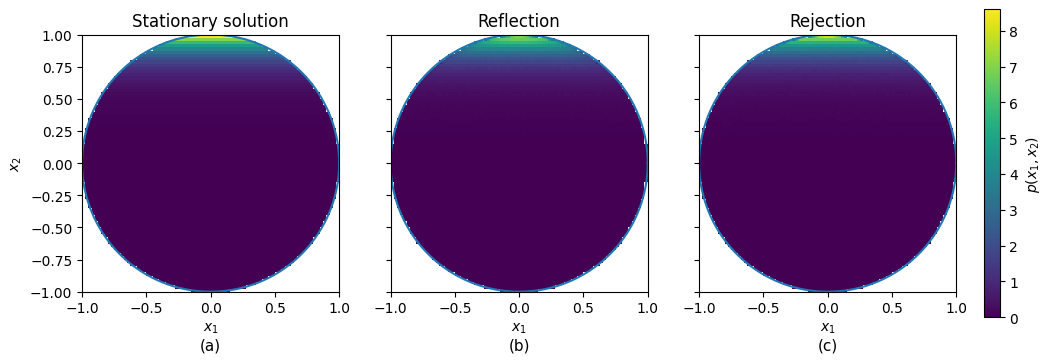

In [4]:
# Anisotropic diffusion in the unit disk
# Stationary solution, reflection and rejection

radius = 1.0
dt = 0.01
bins = 80

b = np.array([0.0, 1.0])
sigma = np.array([[1.0, 0.0],
                  [0.0, 0.5]])

problem_path = "./data/disk_b-0-1_s-M"
boundary_types = ["reflection", "rejection"]

cmap = plt.get_cmap()


# Build Cartesian grid for the stationary reference density
x_edges = np.linspace(-radius, radius, bins + 1)
y_edges = np.linspace(-radius, radius, bins + 1)

x_centres = 0.5 * (x_edges[:-1] + x_edges[1:])
y_centres = 0.5 * (y_edges[:-1] + y_edges[1:])

x_mesh, y_mesh = np.meshgrid(
    x_centres,
    y_centres,
    indexing="ij"
)


# Stationary reference solution
p_exact = stationary_solution_disk(
    x_mesh,
    y_mesh,
    b,
    sigma,
    radius=radius
)

density_data = {"exact": p_exact}
p_scales = [p_exact]


# Load precomputed numerical solutions
for boundary_type in boundary_types:

    X = load_solution(
        f"{boundary_type}_dt-{dt}.npy",
        problem_path
    )

    p_num, _, _ = histogram_density_disk(
        X,
        radius=radius,
        bins=bins
    )

    density_data[boundary_type] = p_num
    p_scales.append(p_num)


# Shared colour scale
colorbar_values = get_colorbar_values_2d(p_scales)


# Plot
fig, ax = plt.subplots(
    1, 3,
    figsize=(12, 4),
    sharex=True,
    sharey=True
)

plot_density_disk(
    density_data["exact"],
    x_edges,
    y_edges,
    radius=radius,
    ax=ax[0],
    title="Stationary solution",
    colorbar_values=colorbar_values,
    cmap=cmap
)

plot_density_disk(
    density_data["reflection"],
    x_edges,
    y_edges,
    radius=radius,
    ax=ax[1],
    title="Reflection",
    colorbar_values=colorbar_values,
    cmap=cmap
)

plot_density_disk(
    density_data["rejection"],
    x_edges,
    y_edges,
    radius=radius,
    ax=ax[2],
    title="Rejection",
    colorbar_values=colorbar_values,
    cmap=cmap
)


# Axis labels and formatting
for a in ax:
    a.set_xlabel(r"$x_1$")
    a.set_ylabel("")
    a.set_aspect("equal")

ax[0].set_ylabel(r"$x_2$")


# Shared colourbar
add_shared_colorbar(
    fig,
    ax,
    colorbar_values,
    cmap=cmap,
    label=r"$p(x_1,x_2)$"
)


# Panel labels
panel_labels = ["(a)", "(b)", "(c)"]

for a, label in zip(ax, panel_labels):
    a.annotate(
        label,
        xy=(0.5, -0.18),
        xycoords="axes fraction",
        ha="center",
        va="top",
        fontsize=11,
        annotation_clip=False
    )

plt.show()

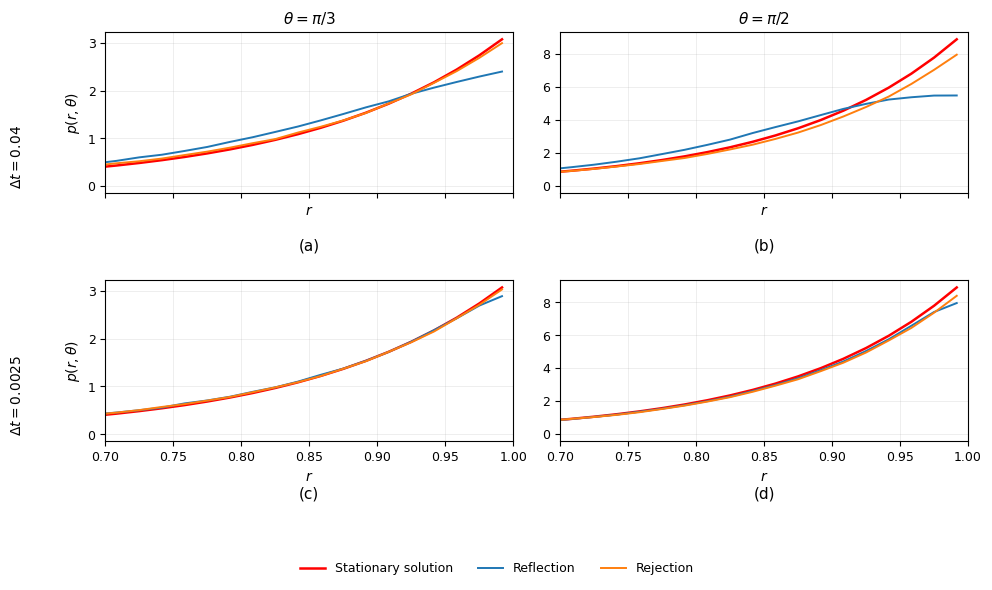

In [5]:
# Anisotropic diffusion in the unit disk
# Radial slices for two time steps and two angles

radius = 1.0
b = np.array([0.0, 1.0])
sigma = np.array([[1.0, 0.0],
                  [0.0, 0.5]])

problem_path = "./data/disk_b-0-1_s-M"
boundary_types = ["reflection", "rejection"]

dt_list = [0.04, 0.0025]
theta_list = [np.pi/3, np.pi/2]
theta_labels = [
    r"$\theta=\pi/3$",
    r"$\theta=\pi/2$"
]

# radial bins
n_r = 60
r_edges = np.linspace(0.0, radius, n_r + 1)
r_centres = 0.5 * (r_edges[:-1] + r_edges[1:])

# angular half-width for the wedge
delta_theta = np.pi / 36   # 5 degrees


def angle_distance(theta, theta0):
    """
    Smallest absolute angular distance between theta and theta0.
    """
    return np.abs(np.angle(np.exp(1j * (theta - theta0))))


def radial_density_slice(X, theta0, r_edges, delta_theta):
    """
    Estimate the 2D density along a radial slice by averaging over
    a thin angular wedge around theta0.
    """
    x1 = X[:, 0]
    x2 = X[:, 1]

    r = np.sqrt(x1**2 + x2**2)
    theta = np.mod(np.arctan2(x2, x1), 2*np.pi)

    mask_theta = angle_distance(theta, theta0) <= delta_theta
    r_sel = r[mask_theta]

    counts, _ = np.histogram(r_sel, bins=r_edges)

    # area of each annular sector bin with angle width 2*delta_theta
    area = delta_theta * (r_edges[1:]**2 - r_edges[:-1]**2)

    density = counts / (X.shape[0] * area)

    return density


fig, ax = plt.subplots(
    len(dt_list), len(theta_list),
    figsize=(10, 5.8),
    sharex=True,
    sharey="col"
)

ax = np.atleast_2d(ax)

for row, dt in enumerate(dt_list):

    # Load numerical solutions
    X_ref = load_solution(
        f"reflection_dt-{dt}.npy",
        problem_path
    )

    X_rej = load_solution(
        f"rejection_dt-{dt}.npy",
        problem_path
    )

    for col, (theta0, theta_label) in enumerate(zip(theta_list, theta_labels)):

        # exact radial profile
        x_curve = r_centres * np.cos(theta0)
        y_curve = r_centres * np.sin(theta0)

        p_exact = stationary_solution_disk(
            x_curve,
            y_curve,
            b,
            sigma,
            radius=radius
        )

        # numerical radial profiles
        p_ref = radial_density_slice(
            X_ref,
            theta0,
            r_edges,
            delta_theta
        )

        p_rej = radial_density_slice(
            X_rej,
            theta0,
            r_edges,
            delta_theta
        )

        # plot
        stationary_line, = ax[row, col].plot(
            r_centres,
            p_exact,
            color="red",
            linewidth=1.8,
            label="Stationary solution"
        )

        reflection_line, = ax[row, col].plot(
            r_centres,
            p_ref,
            linewidth=1.4,
            label="Reflection"
        )

        rejection_line, = ax[row, col].plot(
            r_centres,
            p_rej,
            linewidth=1.4,
            label="Rejection"
        )

        if row == 0:
            ax[row, col].set_title(theta_label, fontsize=11)

        ax[row, col].set_xlabel(r"$r$", fontsize=10)
        ax[row, col].tick_params(axis="both", labelsize=9)
        ax[row, col].grid(True, alpha=0.25, linewidth=0.6)
        ax[row, col].set_xlim(0.7, 1.0)

# shared y-labels by column
ax[0, 0].set_ylabel(r"$p(r,\theta)$", fontsize=10)
ax[1, 0].set_ylabel(r"$p(r,\theta)$", fontsize=10)

# row labels for time step
fig.text(
    0.02, 0.72,
    r"$\Delta t=0.04$",
    rotation=90,
    va="center",
    ha="center",
    fontsize=10
)

fig.text(
    0.02, 0.31,
    r"$\Delta t=0.0025$",
    rotation=90,
    va="center",
    ha="center",
    fontsize=10
)

# one legend for the whole figure
fig.legend(
    handles=[stationary_line, reflection_line, rejection_line],
    labels=["Stationary solution", "Reflection", "Rejection"],
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=3,
    frameon=False,
    fontsize=9
)

# panel labels
panel_labels = ["(a)", "(b)", "(c)", "(d)"]
for label, a in zip(panel_labels, ax.ravel()):
    a.annotate(
        label,
        xy=(0.5, -0.28),
        xycoords="axes fraction",
        ha="center",
        va="top",
        fontsize=11,
        annotation_clip=False
    )

fig.tight_layout(rect=[0.04, 0.08, 1, 1])

plt.show()

## bounary and convergance

### full domain abslute error

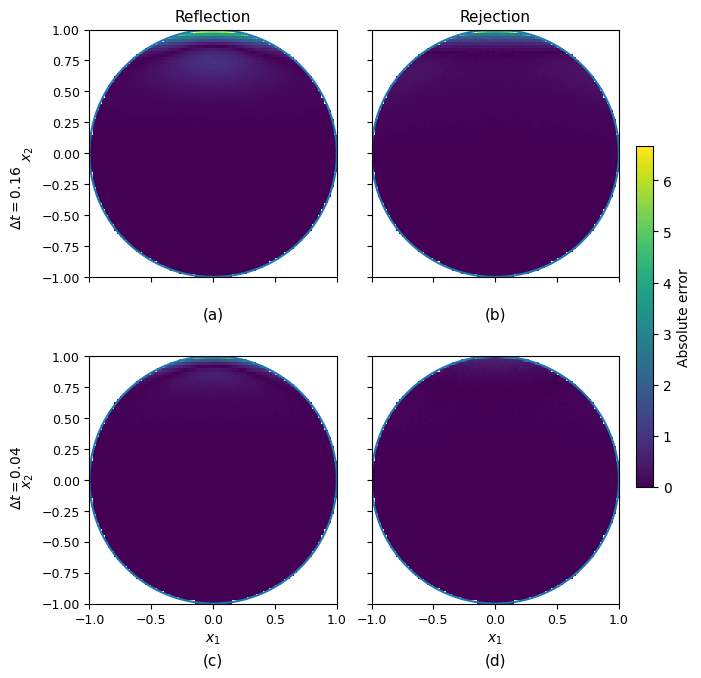

,boundary_type,dt,epsilon,L1_error,L2_error,relative_error
0,reflection,0.16,0.4,0.459222,0.908532,0.487363
1,reflection,0.04,0.2,0.201882,0.519914,0.278897
2,rejection,0.16,0.4,0.324543,0.661059,0.354611
3,rejection,0.04,0.2,0.108176,0.285440,0.153119


In [6]:
# Full-domain absolute local error
# Anisotropic diffusion in the unit disk

radius = 1.0
bins = 80

b = np.array([0.0, 1.0])
sigma = np.array([
    [1.0, 0.0],
    [0.0, 0.5]
])

problem_path = "./data/disk_b-0-1_s-M"

boundary_types = ["reflection", "rejection"]
dt_list = [0.16, 0.04]

cmap = plt.get_cmap()

full_error_rows = []
plot_data = {}
vmax = 0.0


# --------------------------------------------------
# Compute error fields
# --------------------------------------------------

for boundary_type in boundary_types:

    plot_data[boundary_type] = {}

    for dt in dt_list:

        X = load_solution(
            f"{boundary_type}_dt-{dt}.npy",
            problem_path
        )

        p_num, x_edges, y_edges = histogram_density_disk(
            X,
            radius=radius,
            bins=bins
        )

        # Cartesian bin centres
        x_centres = 0.5 * (x_edges[:-1] + x_edges[1:])
        y_centres = 0.5 * (y_edges[:-1] + y_edges[1:])

        x_mesh, y_mesh = np.meshgrid(
            x_centres,
            y_centres,
            indexing="ij"
        )

        # Stationary reference solution
        p_true = stationary_solution_disk(
            x_mesh,
            y_mesh,
            b,
            sigma,
            radius=radius
        )

        # Local error
        error = local_error_density(
            p_num,
            p_true
        )

        abs_error = np.abs(error)

        # Error measures for later convergence analysis
        L1_error, L2_error, relative_error = density_error_norms_cartesian(
            error,
            p_true,
            x_edges,
            y_edges
        )

        full_error_rows.append({
            "boundary_type": boundary_type,
            "dt": dt,
            "epsilon": np.sqrt(dt),
            "L1_error": L1_error,
            "L2_error": L2_error,
            "relative_error": relative_error
        })

        plot_data[boundary_type][dt] = (
            abs_error,
            x_edges,
            y_edges
        )

        vmax = max(
            vmax,
            np.nanmax(abs_error)
        )


# --------------------------------------------------
# Plot
# --------------------------------------------------

colorbar_values = (0, vmax)

fig, ax = plt.subplots(
    2, 2,
    figsize=(8, 7),
    sharex=True,
    sharey=True
)

for row, dt in enumerate(dt_list):

    for col, boundary_type in enumerate(boundary_types):

        abs_error, x_edges, y_edges = plot_data[boundary_type][dt]

        plot_density_disk(
            abs_error,
            x_edges,
            y_edges,
            radius=radius,
            ax=ax[row, col],
            title="",
            colorbar_values=colorbar_values,
            cmap=cmap
        )

        ax[row, col].set_aspect("equal")
        ax[row, col].set_xlabel("")
        ax[row, col].set_ylabel("")
        ax[row, col].tick_params(
            axis="both",
            labelsize=9
        )

        # Column titles
        if row == 0:
            ax[row, col].set_title(
                "Reflection" if boundary_type == "reflection"
                else "Rejection",
                fontsize=11
            )

        # Hide duplicated tick labels
        if row == 0:
            ax[row, col].tick_params(labelbottom=False)

        if col == 1:
            ax[row, col].tick_params(labelleft=False)


# Axis labels
ax[0, 0].set_ylabel(r"$x_2$", fontsize=10)
ax[1, 0].set_ylabel(r"$x_2$", fontsize=10)

ax[1, 0].set_xlabel(r"$x_1$", fontsize=10)
ax[1, 1].set_xlabel(r"$x_1$", fontsize=10)


# Fix subplot positions BEFORE adding colourbar
fig.subplots_adjust(
    left=0.13,
    right=0.84,
    bottom=0.12,
    top=0.94,
    wspace=0.12,
    hspace=0.32
)


# Row labels
fig.text(
    0.045,
    0.70,
    r"$\Delta t=0.16$",
    rotation=90,
    ha="center",
    va="center",
    fontsize=10
)

fig.text(
    0.045,
    0.30,
    r"$\Delta t=0.04$",
    rotation=90,
    ha="center",
    va="center",
    fontsize=10
)


# Shared colourbar using your function
add_shared_colorbar(
    fig,
    ax,
    colorbar_values,
    cmap=cmap,
    label="Absolute error"
)


# Panel labels
panel_labels = ["(a)", "(b)", "(c)", "(d)"]

for row in range(2):
    for col in range(2):

        label = panel_labels[2 * row + col]

        # Top row has no x-axis label
        if row == 0:
            y_pos = -0.12
        else:
            y_pos = -0.20

        ax[row, col].annotate(
            label,
            xy=(0.5, y_pos),
            xycoords="axes fraction",
            ha="center",
            va="top",
            fontsize=11,
            annotation_clip=False
        )


plt.show()


# --------------------------------------------------
# Numerical error table
# --------------------------------------------------

full_error_table = pd.DataFrame(full_error_rows)
display(full_error_table)

### boundary stirp

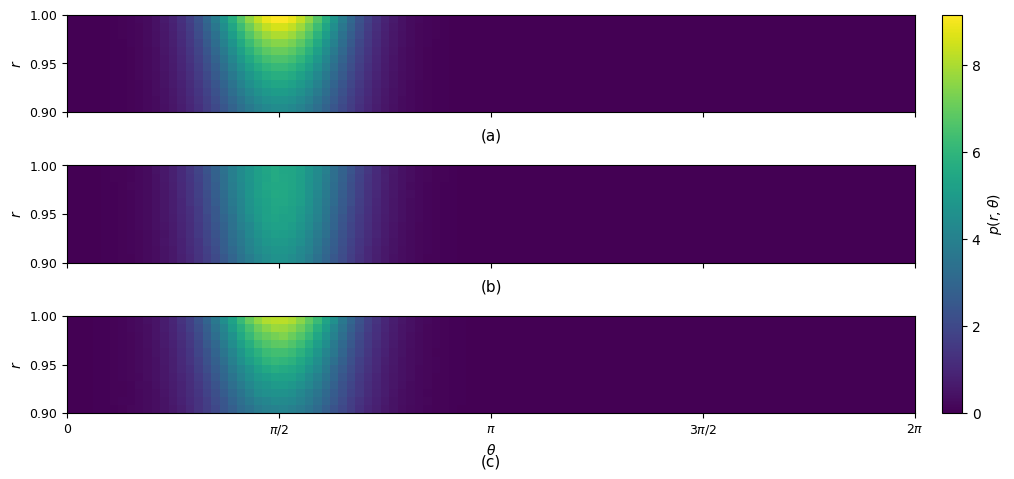

In [7]:
# Boundary-strip density
# Anisotropic diffusion in the unit disk

radius = 1.0
boundary_width = 0.1
dt = 0.04

b = np.array([0.0, 1.0])
sigma = np.array([
    [1.0, 0.0],
    [0.0, 0.5]
])

problem_path = "./data/disk_b-0-1_s-M"
boundary_types = ["reflection", "rejection"]

theta_bins = 100
r_bins = 12

r_range = (radius - boundary_width, radius)

cmap = plt.get_cmap()


# --------------------------------------------------
# Numerical boundary-strip densities
# --------------------------------------------------

density_data = {}

for boundary_type in boundary_types:

    X = load_solution(
        f"{boundary_type}_dt-{dt}.npy",
        problem_path
    )

    p_num, theta_edges, r_edges, counts = density_disk_range(
        X,
        r_range=r_range,
        theta_bins=theta_bins,
        r_bins=r_bins
    )

    density_data[boundary_type] = p_num


# --------------------------------------------------
# Stationary reference density on the same polar grid
# --------------------------------------------------

theta_centres = 0.5 * (theta_edges[:-1] + theta_edges[1:])
r_centres = 0.5 * (r_edges[:-1] + r_edges[1:])

theta_mesh, r_mesh = np.meshgrid(
    theta_centres,
    r_centres,
    indexing="ij"
)

x_mesh = r_mesh * np.cos(theta_mesh)
y_mesh = r_mesh * np.sin(theta_mesh)

p_true = stationary_solution_disk(
    x_mesh,
    y_mesh,
    b,
    sigma,
    radius=radius
)

density_data["exact"] = p_true


# --------------------------------------------------
# Shared colour scale
# --------------------------------------------------

colorbar_values = get_colorbar_values_2d([
    density_data["exact"],
    density_data["reflection"],
    density_data["rejection"]
])


# --------------------------------------------------
# Plot
# --------------------------------------------------

fig, ax = plt.subplots(
    3, 1,
    figsize=(11, 4.8),
    sharex=True,
    sharey=True
)

plot_data = [
    density_data["exact"],
    density_data["reflection"],
    density_data["rejection"]
]

for i, density in enumerate(plot_data):

    plot_density_disk_range(
        density,
        theta_edges,
        r_edges,
        ax=ax[i],
        title=None,
        colorbar_values=colorbar_values,
        cmap=cmap
    )

    ax[i].tick_params(axis="both", labelsize=9)
    ax[i].set_ylabel(r"$r$", fontsize=10)

    if i < 2:
        ax[i].set_xlabel("")
    else:
        ax[i].set_xlabel(r"$\theta$", fontsize=10)


# Optional: nicer theta ticks
theta_tick_positions = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
theta_tick_labels = [
    r"$0$",
    r"$\pi/2$",
    r"$\pi$",
    r"$3\pi/2$",
    r"$2\pi$"
]

for a in ax:
    a.set_xticks(theta_tick_positions)

ax[-1].set_xticklabels(theta_tick_labels)


# --------------------------------------------------
# Layout before colorbar
# --------------------------------------------------

fig.subplots_adjust(
    left=0.08,
    right=0.90,
    bottom=0.14,
    top=0.97,
    hspace=0.55
)


# --------------------------------------------------
# Shared colourbar
# --------------------------------------------------

add_shared_colorbar(
    fig,
    ax,
    colorbar_values,
    cmap=cmap,
    label=r"$p(r,\theta)$"
)


# --------------------------------------------------
# Panel labels
# --------------------------------------------------

panel_labels = ["(a)", "(b)", "(c)"]

for i, (a, label) in enumerate(zip(ax, panel_labels)):

    if i < 2:
        y_pos = -0.17
    else:
        y_pos = -0.42

    a.annotate(
        label,
        xy=(0.5, y_pos),
        xycoords="axes fraction",
        ha="center",
        va="top",
        fontsize=11,
        annotation_clip=False
    )

plt.show()

### radial error

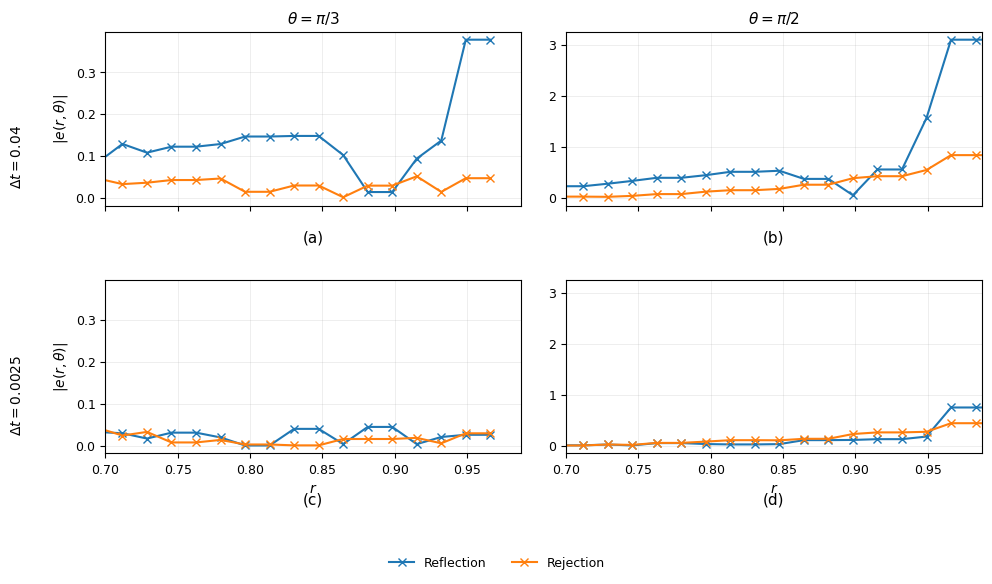

In [8]:
# Full-domain absolute error radial slices
# Anisotropic diffusion in the unit disk

radius = 1.0
bins = 80
r_bins = 60

b = np.array([0.0, 1.0])
sigma = np.array([
    [1.0, 0.0],
    [0.0, 0.5]
])

problem_path = "./data/disk_b-0-1_s-M"

boundary_types = ["reflection", "rejection"]
dt_list = [0.04, 0.0025]

angles = [np.pi/3, np.pi/2]
angle_labels = [
    r"$\theta=\pi/3$",
    r"$\theta=\pi/2$"
]

fig, ax = plt.subplots(
    len(dt_list),
    len(angles),
    figsize=(10, 5.8),
    sharex=True,
    sharey="col"
)

ax = np.atleast_2d(ax)

for row, dt in enumerate(dt_list):

    error_data = {}

    for boundary_type in boundary_types:

        X = load_solution(
            f"{boundary_type}_dt-{dt}.npy",
            problem_path
        )

        p_num, x_edges, y_edges = histogram_density_disk(
            X,
            radius=radius,
            bins=bins
        )

        # Cartesian bin centres
        x_centres = 0.5 * (x_edges[:-1] + x_edges[1:])
        y_centres = 0.5 * (y_edges[:-1] + y_edges[1:])

        x_mesh, y_mesh = np.meshgrid(
            x_centres,
            y_centres,
            indexing="ij"
        )

        p_true = stationary_solution_disk(
            x_mesh,
            y_mesh,
            b,
            sigma,
            radius=radius
        )

        error_data[boundary_type] = np.abs(
            local_error_density(
                p_num,
                p_true
            )
        )

    for col, theta_0 in enumerate(angles):

        for boundary_type in boundary_types:

            r, values = field_disk_radial_slice(
                error_data[boundary_type],
                x_edges,
                y_edges,
                theta_0=theta_0,
                radius=radius,
                r_bins=r_bins
            )

            # Remove masked Cartesian cells
            valid = np.isfinite(values)
            r_plot = r[valid]
            values_plot = values[valid]

            plot_radial_slice(
                r_plot,
                values_plot,
                ax=ax[row, col],
                title="",
                label=boundary_type,
                y_label=r"$|e(r,\theta)|$"
            )

        # Remove individual legends created by plot_radial_slice
        if ax[row, col].legend_ is not None:
            ax[row, col].legend_.remove()

        # Column titles
        if row == 0:
            ax[row, col].set_title(
                angle_labels[col],
                fontsize=11
            )

        ax[row, col].grid(
            True,
            alpha=0.25,
            linewidth=0.6
        )

        ax[row, col].tick_params(
            axis="both",
            labelsize=9
        )

        # x label only on bottom row
        if row == 1:
            ax[row, col].set_xlabel(
                r"$r$",
                fontsize=10
            )
        else:
            ax[row, col].set_xlabel("")


# --------------------------------------------------
# Radial plotting range
# --------------------------------------------------

dx = x_edges[1] - x_edges[0]
dy = y_edges[1] - y_edges[0]
r_plot_max = radius - 0.5 * min(dx, dy)

for a in ax.ravel():
    a.set_xlim(0.7, r_plot_max)


# --------------------------------------------------
# Axis labels
# --------------------------------------------------

ax[0, 0].set_ylabel(
    r"$|e(r,\theta)|$",
    fontsize=10
)

ax[1, 0].set_ylabel(
    r"$|e(r,\theta)|$",
    fontsize=10
)

ax[0, 1].set_ylabel("")
ax[1, 1].set_ylabel("")


# --------------------------------------------------
# Row labels
# --------------------------------------------------

fig.text(
    0.02,
    0.72,
    r"$\Delta t=0.04$",
    rotation=90,
    ha="center",
    va="center",
    fontsize=10
)

fig.text(
    0.02,
    0.31,
    r"$\Delta t=0.0025$",
    rotation=90,
    ha="center",
    va="center",
    fontsize=10
)


# --------------------------------------------------
# Shared legend
# --------------------------------------------------

fig.legend(
    handles=[
        ax[0, 0].lines[0],
        ax[0, 0].lines[1]
    ],
    labels=[
        "Reflection",
        "Rejection"
    ],
    loc="lower center",
    bbox_to_anchor=(0.5, -0.01),
    ncol=2,
    frameon=False,
    fontsize=9
)


# --------------------------------------------------
# Panel labels
# --------------------------------------------------

panel_labels = ["(a)", "(b)", "(c)", "(d)"]

for row in range(2):
    for col in range(2):

        label = panel_labels[2 * row + col]
        y_position = -0.14 if row == 0 else -0.22

        ax[row, col].annotate(
            label,
            xy=(0.5, y_position),
            xycoords="axes fraction",
            ha="center",
            va="top",
            fontsize=11,
            annotation_clip=False
        )


fig.tight_layout(
    rect=[0.04, 0.08, 1, 1],
    h_pad=2.2
)

plt.show()

### boundary error strip

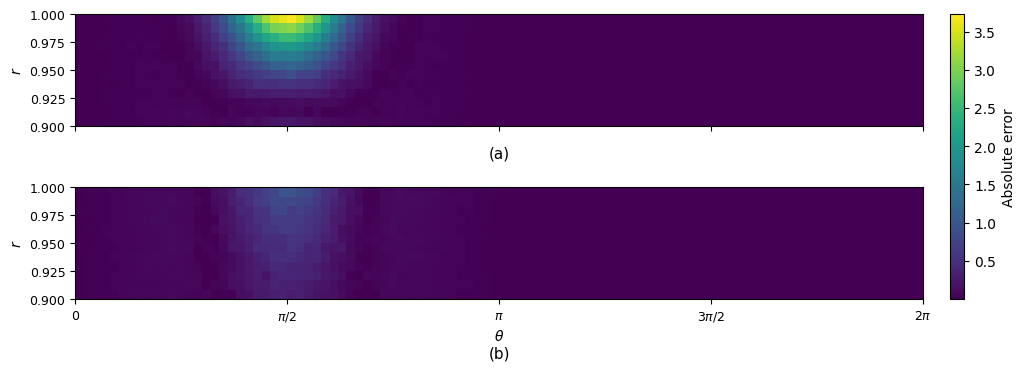

In [9]:
# Boundary-strip absolute error
# Anisotropic diffusion in the unit disk

radius = 1.0
boundary_width = 0.1
dt = 0.04

b = np.array([0.0, 1.0])
sigma = np.array([
    [1.0, 0.0],
    [0.0, 0.5]
])

problem_path = "./data/disk_b-0-1_s-M"
boundary_types = ["reflection", "rejection"]

theta_bins = 100
r_bins = 12

r_range = (radius - boundary_width, radius)

cmap = plt.get_cmap()


# --------------------------------------------------
# Numerical boundary-strip densities
# --------------------------------------------------

density_data = {}

for boundary_type in boundary_types:

    X = load_solution(
        f"{boundary_type}_dt-{dt}.npy",
        problem_path
    )

    p_num, theta_edges, r_edges, counts = density_disk_range(
        X,
        r_range=r_range,
        theta_bins=theta_bins,
        r_bins=r_bins
    )

    density_data[boundary_type] = p_num


# --------------------------------------------------
# Stationary reference density on the same polar grid
# --------------------------------------------------

theta_centres = 0.5 * (theta_edges[:-1] + theta_edges[1:])
r_centres = 0.5 * (r_edges[:-1] + r_edges[1:])

theta_mesh, r_mesh = np.meshgrid(
    theta_centres,
    r_centres,
    indexing="ij"
)

x_mesh = r_mesh * np.cos(theta_mesh)
y_mesh = r_mesh * np.sin(theta_mesh)

p_true = stationary_solution_disk(
    x_mesh,
    y_mesh,
    b,
    sigma,
    radius=radius
)


# --------------------------------------------------
# Absolute error on the boundary strip
# --------------------------------------------------

error_data = {
    "reflection": np.abs(density_data["reflection"] - p_true),
    "rejection": np.abs(density_data["rejection"] - p_true)
}


# --------------------------------------------------
# Shared colour scale
# --------------------------------------------------

colorbar_values = get_colorbar_values_2d([
    error_data["reflection"],
    error_data["rejection"]
])


# --------------------------------------------------
# Plot
# --------------------------------------------------

fig, ax = plt.subplots(
    2, 1,
    figsize=(11, 3.8),
    sharex=True,
    sharey=True
)

plot_data = [
    error_data["reflection"],
    error_data["rejection"]
]

for i, error in enumerate(plot_data):

    plot_density_disk_range(
        error,
        theta_edges,
        r_edges,
        ax=ax[i],
        title=None,
        colorbar_values=colorbar_values,
        cmap=cmap
    )

    ax[i].tick_params(axis="both", labelsize=9)
    ax[i].set_ylabel(r"$r$", fontsize=10)

    if i == 0:
        ax[i].set_xlabel("")
    else:
        ax[i].set_xlabel(r"$\theta$", fontsize=10)


# Optional: nicer theta ticks
theta_tick_positions = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
theta_tick_labels = [
    r"$0$",
    r"$\pi/2$",
    r"$\pi$",
    r"$3\pi/2$",
    r"$2\pi$"
]

for a in ax:
    a.set_xticks(theta_tick_positions)

ax[-1].set_xticklabels(theta_tick_labels)


# --------------------------------------------------
# Layout before colorbar
# --------------------------------------------------

fig.subplots_adjust(
    left=0.08,
    right=0.90,
    bottom=0.22,
    top=0.97,
    hspace=0.55
)


# --------------------------------------------------
# Shared colourbar
# --------------------------------------------------

add_shared_colorbar(
    fig,
    ax,
    colorbar_values,
    cmap=cmap,
    label="Absolute error"
)


# --------------------------------------------------
# Panel labels
# --------------------------------------------------

panel_labels = ["(a)", "(b)"]

for i, (a, label) in enumerate(zip(ax, panel_labels)):

    if i == 0:
        y_pos = -0.18
    else:
        y_pos = -0.42

    a.annotate(
        label,
        xy=(0.5, y_pos),
        xycoords="axes fraction",
        ha="center",
        va="top",
        fontsize=11,
        annotation_clip=False
    )

plt.show()

### Convergence plot

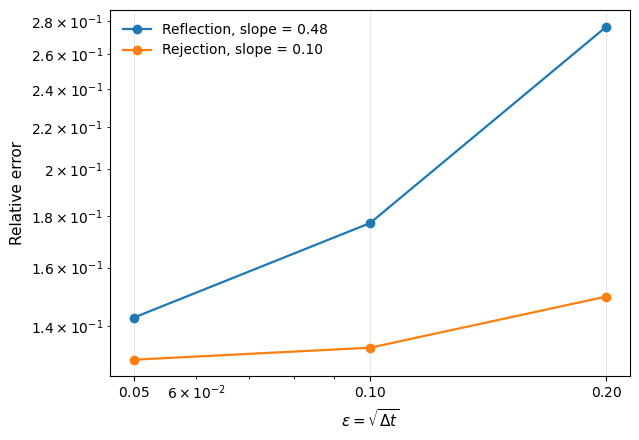

,boundary_type,observed_order
0,reflection,0.476750
1,rejection,0.103513


In [10]:
# Full-domain convergence
# Anisotropic diffusion in the unit disk

radius = 1.0
bins = 100

b = np.array([0.0, 1.0])
sigma = np.array([
    [1.0, 0.0],
    [0.0, 0.5]
])

problem_path = "./data/disk_b-0-1_s-M"

boundary_types = ["reflection", "rejection"]
dt_list = [0.04, 0.01, 0.0025]

full_error_rows = []


# --------------------------------------------------
# Compute full-domain errors
# --------------------------------------------------

for boundary_type in boundary_types:

    for dt in dt_list:

        X = load_solution(
            f"{boundary_type}_dt-{dt}.npy",
            problem_path
        )

        p_num, x_edges, y_edges = histogram_density_disk(
            X,
            radius=radius,
            bins=bins
        )

        x_centres = 0.5 * (x_edges[:-1] + x_edges[1:])
        y_centres = 0.5 * (y_edges[:-1] + y_edges[1:])

        x_mesh, y_mesh = np.meshgrid(
            x_centres,
            y_centres,
            indexing="ij"
        )

        p_true = stationary_solution_disk(
            x_mesh,
            y_mesh,
            b,
            sigma,
            radius=radius
        )

        error = local_error_density(
            p_num,
            p_true
        )

        L1_error, L2_error, relative_error = density_error_norms_cartesian(
            error,
            p_true,
            x_edges,
            y_edges
        )

        full_error_rows.append({
            "boundary_type": boundary_type,
            "dt": dt,
            "epsilon": np.sqrt(dt),
            "relative_error": relative_error
        })


full_error_table = pd.DataFrame(full_error_rows)


# --------------------------------------------------
# Plot
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(6.5, 4.5))

order_rows = []

for boundary_type in boundary_types:

    rows = full_error_table[
        full_error_table["boundary_type"] == boundary_type
    ].sort_values("epsilon")

    epsilon_values = rows["epsilon"].to_numpy()
    errors = rows["relative_error"].to_numpy()

    order = np.polyfit(
        np.log(epsilon_values),
        np.log(errors),
        1
    )[0]

    label = (
        "Reflection"
        if boundary_type == "reflection"
        else "Rejection"
    )

    ax.loglog(
        epsilon_values,
        errors,
        marker="o",
        markersize=6,
        linewidth=1.6,
        label=fr"{label}, slope = {order:.2f}"
    )

    order_rows.append({
        "boundary_type": boundary_type,
        "observed_order": order
    })


# --------------------------------------------------
# Formatting
# --------------------------------------------------

ax.set_xlabel(
    r"$\varepsilon=\sqrt{\Delta t}$",
    fontsize=11
)

ax.set_ylabel(
    "Relative error",
    fontsize=11
)

ax.set_xticks([0.05, 0.10, 0.20])
ax.set_xticklabels([
    r"$0.05$",
    r"$0.10$",
    r"$0.20$"
])

ax.grid(
    True,
    which="major",
    alpha=0.3,
    linewidth=0.7
)

ax.legend(
    fontsize=10,
    frameon=False
)

ax.tick_params(
    axis="both",
    labelsize=10
)

fig.tight_layout()

plt.show()


full_convergence_table = pd.DataFrame(order_rows)
display(full_convergence_table)

### convergence over the strip

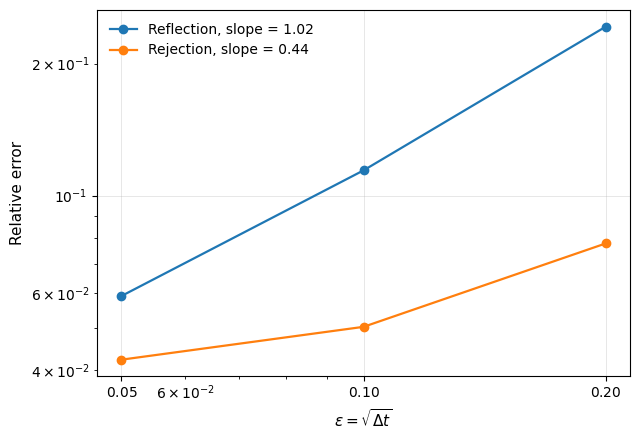

,boundary_type,observed_order
0,reflection,1.020016
1,rejection,0.440272


In [11]:
# Boundary-strip convergence
# Anisotropic diffusion in the unit disk

radius = 1.0
boundary_width = 0.1

theta_bins = 100
r_bins = 12

b = np.array([0.0, 1.0])
sigma = np.array([
    [1.0, 0.0],
    [0.0, 0.5]
])

problem_path = "./data/disk_b-0-1_s-M"

boundary_types = ["reflection", "rejection"]
dt_list = [0.04, 0.01, 0.0025]

r_range = (
    radius - boundary_width,
    radius
)

boundary_error_rows = []


# --------------------------------------------------
# Compute boundary-strip errors
# --------------------------------------------------

for boundary_type in boundary_types:

    for dt in dt_list:

        X = load_solution(
            f"{boundary_type}_dt-{dt}.npy",
            problem_path
        )

        p_num, theta_edges, r_edges, counts = density_disk_range(
            X,
            r_range=r_range,
            theta_bins=theta_bins,
            r_bins=r_bins
        )

        theta_centres = 0.5 * (
            theta_edges[:-1] + theta_edges[1:]
        )

        r_centres = 0.5 * (
            r_edges[:-1] + r_edges[1:]
        )

        theta_mesh, r_mesh = np.meshgrid(
            theta_centres,
            r_centres,
            indexing="ij"
        )

        x_mesh = r_mesh * np.cos(theta_mesh)
        y_mesh = r_mesh * np.sin(theta_mesh)

        p_true = stationary_solution_disk(
            x_mesh,
            y_mesh,
            b,
            sigma,
            radius=radius
        )

        error = local_error_density(
            p_num,
            p_true
        )

        L1_error, L2_error, relative_error = density_error_norms(
            error,
            p_true,
            theta_edges,
            r_edges
        )

        boundary_error_rows.append({
            "boundary_type": boundary_type,
            "dt": dt,
            "epsilon": np.sqrt(dt),
            "relative_error": relative_error
        })


boundary_error_table = pd.DataFrame(boundary_error_rows)


# --------------------------------------------------
# Plot
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(6.5, 4.5))

order_rows = []

for boundary_type in boundary_types:

    rows = boundary_error_table[
        boundary_error_table["boundary_type"] == boundary_type
    ].sort_values("epsilon")

    epsilon_values = rows["epsilon"].to_numpy()
    errors = rows["relative_error"].to_numpy()

    order = np.polyfit(
        np.log(epsilon_values),
        np.log(errors),
        1
    )[0]

    label = (
        "Reflection"
        if boundary_type == "reflection"
        else "Rejection"
    )

    ax.loglog(
        epsilon_values,
        errors,
        marker="o",
        markersize=6,
        linewidth=1.6,
        label=fr"{label}, slope = {order:.2f}"
    )

    order_rows.append({
        "boundary_type": boundary_type,
        "observed_order": order
    })


# --------------------------------------------------
# Formatting
# --------------------------------------------------

ax.set_xlabel(
    r"$\varepsilon=\sqrt{\Delta t}$",
    fontsize=11
)

ax.set_ylabel(
    "Relative error",
    fontsize=11
)

ax.set_xticks([0.05, 0.10, 0.20])
ax.set_xticklabels([
    r"$0.05$",
    r"$0.10$",
    r"$0.20$"
])

ax.grid(
    True,
    which="major",
    alpha=0.3,
    linewidth=0.7
)

ax.legend(
    fontsize=10,
    frameon=False
)

ax.tick_params(
    axis="both",
    labelsize=10
)

fig.tight_layout()

plt.show()


boundary_convergence_table = pd.DataFrame(order_rows)
display(boundary_convergence_table)

### stretched boundary

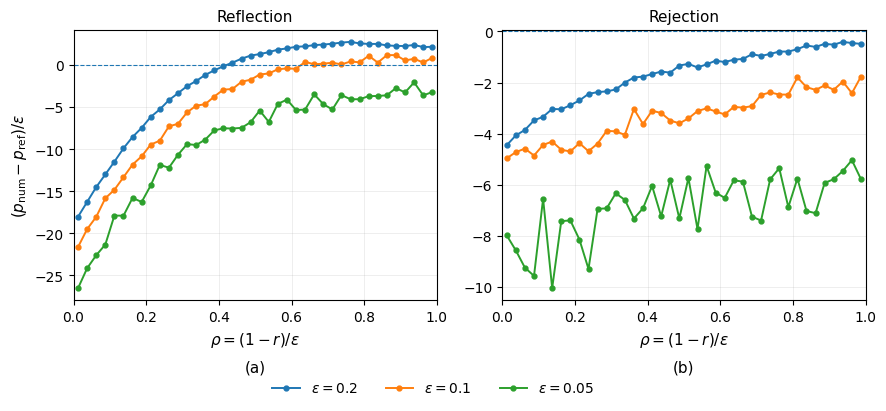

In [12]:
# Stretched boundary-layer error profiles
# Averaged over a small angular wedge around theta = pi/2

radius = 1.0

b = np.array([0.0, 1.0])
sigma = np.array([
    [1.0, 0.0],
    [0.0, 0.5]
])

problem_path = "./data/disk_b-0-1_s-M"

boundary_types = ["reflection", "rejection"]
boundary_titles = {
    "reflection": "Reflection",
    "rejection": "Rejection"
}

dt_list = [0.04, 0.01, 0.0025]

theta_0 = np.pi / 2
theta_half_width = np.pi / 18   # +/- 10 degrees

theta_bins = 180
r_bins = 40


# --------------------------------------------------
# Compute stretched profiles
# --------------------------------------------------

profile_data = {}

for boundary_type in boundary_types:

    for dt in dt_list:

        epsilon = np.sqrt(dt)

        # physical boundary strip of width epsilon
        r_range = (
            radius - epsilon,
            radius
        )

        X = load_solution(
            f"{boundary_type}_dt-{dt}.npy",
            problem_path
        )

        p_num, theta_edges, r_edges, counts = density_disk_range(
            X,
            r_range=r_range,
            theta_bins=theta_bins,
            r_bins=r_bins
        )

        # bin centres
        theta_centres = 0.5 * (
            theta_edges[:-1] + theta_edges[1:]
        )

        r_centres = 0.5 * (
            r_edges[:-1] + r_edges[1:]
        )

        # stationary reference density on the same polar grid
        theta_mesh, r_mesh = np.meshgrid(
            theta_centres,
            r_centres,
            indexing="ij"
        )

        x_mesh = r_mesh * np.cos(theta_mesh)
        y_mesh = r_mesh * np.sin(theta_mesh)

        p_ref = stationary_solution_disk(
            x_mesh,
            y_mesh,
            b,
            sigma,
            radius=radius
        )

        # angular wedge around theta = pi/2
        theta_mask = (
            (theta_centres >= theta_0 - theta_half_width)
            &
            (theta_centres <= theta_0 + theta_half_width)
        )

        if not np.any(theta_mask):
            raise ValueError("Angular wedge is empty. Increase theta_bins or theta_half_width.")

        # wedge-averaged radial profiles
        p_num_profile = np.nanmean(
            p_num[theta_mask, :],
            axis=0
        )

        p_ref_profile = np.nanmean(
            p_ref[theta_mask, :],
            axis=0
        )

        # signed scaled error
        scaled_error = (
            p_num_profile - p_ref_profile
        ) / epsilon

        # stretched coordinate rho = (1-r)/epsilon
        rho = (
            radius - r_centres
        ) / epsilon

        # sort so rho increases from 0 to 1
        order = np.argsort(rho)

        profile_data[(boundary_type, dt)] = {
            "rho": rho[order],
            "error": scaled_error[order]
        }


# --------------------------------------------------
# Plot
# --------------------------------------------------

fig, ax = plt.subplots(
    1, 2,
    figsize=(9, 4.3),
    sharex=True
)

for i, boundary_type in enumerate(boundary_types):

    for dt in dt_list:

        epsilon = np.sqrt(dt)

        data = profile_data[(boundary_type, dt)]

        ax[i].plot(
            data["rho"],
            data["error"],
            marker="o",
            markersize=3.5,
            linewidth=1.4,
            label=fr"$\varepsilon={epsilon:g}$"
        )

    ax[i].axhline(
        0,
        linestyle="--",
        linewidth=0.8
    )

    ax[i].set_title(
        boundary_titles[boundary_type],
        fontsize=11
    )

    ax[i].set_xlim(0, 1)

    ax[i].set_xlabel(
        r"$\rho=(1-r)/\varepsilon$",
        fontsize=11
    )

    ax[i].grid(
        True,
        alpha=0.25,
        linewidth=0.6
    )

    ax[i].tick_params(
        axis="both",
        labelsize=10
    )


# y label only on left panel
ax[0].set_ylabel(
    r"$(p_{\mathrm{num}}-p_{\mathrm{ref}})/\varepsilon$",
    fontsize=11
)


# --------------------------------------------------
# Shared legend
# --------------------------------------------------

handles, labels = ax[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.02),
    ncol=3,
    frameon=False,
    fontsize=10
)


# --------------------------------------------------
# Panel labels
# --------------------------------------------------

panel_labels = ["(a)", "(b)"]

for a, label in zip(ax, panel_labels):
    a.annotate(
        label,
        xy=(0.5, -0.22),
        xycoords="axes fraction",
        ha="center",
        va="top",
        fontsize=11,
        annotation_clip=False
    )


# --------------------------------------------------
# Layout
# --------------------------------------------------

fig.subplots_adjust(
    left=0.10,
    right=0.98,
    bottom=0.27,
    top=0.90,
    wspace=0.18
)

plt.show()

## Normal vs Oblique reflection

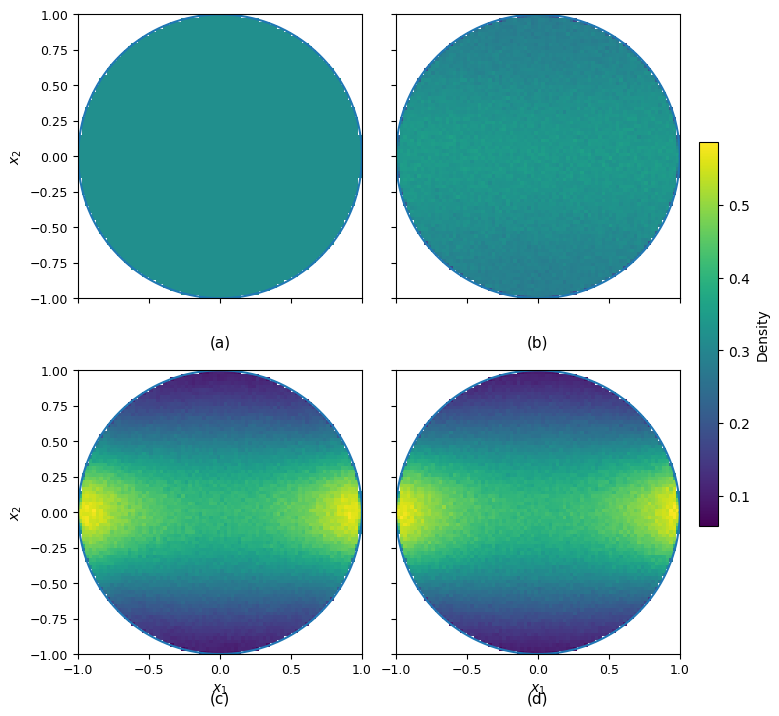

In [14]:
# Normal vs oblique reflection
# Anisotropic diffusion in the unit disk

radius = 1.0
bins = 80

b = np.array([0.0, 0.0])
sigma = np.array([
    [1.0, 0.0],
    [0.0, 0.5]
])

problem_path = "./data/disk_b-0-0_s-M"

dt_oblique = 0.01
dt_normal_1 = 0.01
dt_normal_2 = 0.0025

cmap = plt.get_cmap()


# --------------------------------------------------
# Stationary reference density
# --------------------------------------------------

x_edges = np.linspace(
    -radius,
    radius,
    bins + 1
)

y_edges = np.linspace(
    -radius,
    radius,
    bins + 1
)

x_centres = 0.5 * (
    x_edges[:-1] + x_edges[1:]
)

y_centres = 0.5 * (
    y_edges[:-1] + y_edges[1:]
)

x_mesh, y_mesh = np.meshgrid(
    x_centres,
    y_centres,
    indexing="ij"
)

p_ref = stationary_solution_disk(
    x_mesh,
    y_mesh,
    b,
    sigma,
    radius=radius
)


# --------------------------------------------------
# Oblique reflection
# --------------------------------------------------

X_oblique = load_solution(
    f"reflection_dt-{dt_oblique}.npy",
    problem_path
)

p_oblique, _, _ = histogram_density_disk(
    X_oblique,
    radius=radius,
    bins=bins
)


# --------------------------------------------------
# Forced normal reflection
# --------------------------------------------------

X_normal_1 = load_solution(
    f"reflect_norm_dt-{dt_normal_1}.npy",
    problem_path
)

p_normal_1, _, _ = histogram_density_disk(
    X_normal_1,
    radius=radius,
    bins=bins
)


X_normal_2 = load_solution(
    f"reflect_norm_dt-{dt_normal_2}.npy",
    problem_path
)

p_normal_2, _, _ = histogram_density_disk(
    X_normal_2,
    radius=radius,
    bins=bins
)


# --------------------------------------------------
# Shared colour scale
# --------------------------------------------------

colorbar_values = get_colorbar_values_2d([
    p_ref,
    p_oblique,
    p_normal_1,
    p_normal_2
])


# --------------------------------------------------
# Plot
# --------------------------------------------------

fig, ax = plt.subplots(
    2, 2,
    figsize=(8, 7.5),
    sharex=True,
    sharey=True
)

plot_data = [
    p_ref,
    p_oblique,
    p_normal_1,
    p_normal_2
]

for a, density in zip(
    ax.ravel(),
    plot_data
):

    plot_density_disk(
        density,
        x_edges,
        y_edges,
        radius=radius,
        ax=a,
        title=None,
        colorbar_values=colorbar_values,
        cmap=cmap,
        show_boundary=True
    )

    a.tick_params(
        axis="both",
        labelsize=9
    )


# --------------------------------------------------
# Axis labels
# --------------------------------------------------

ax[0, 0].set_ylabel(
    r"$x_2$",
    fontsize=10
)

ax[1, 0].set_ylabel(
    r"$x_2$",
    fontsize=10
)

ax[1, 0].set_xlabel(
    r"$x_1$",
    fontsize=10
)

ax[1, 1].set_xlabel(
    r"$x_1$",
    fontsize=10
)

ax[0, 0].set_xlabel("")
ax[0, 1].set_xlabel("")
ax[0, 1].set_ylabel("")
ax[1, 1].set_ylabel("")


# --------------------------------------------------
# Shared colourbar
# --------------------------------------------------

fig.subplots_adjust(
    left=0.08,
    right=0.88,
    bottom=0.10,
    top=0.97,
    wspace=0.12,
    hspace=0.20
)

add_shared_colorbar(
    fig,
    ax,
    colorbar_values,
    cmap=cmap,
    label="Density"
)


# --------------------------------------------------
# Panel labels
# --------------------------------------------------

panel_labels = [
    "(a)",
    "(b)",
    "(c)",
    "(d)"
]

for a, label in zip(
    ax.ravel(),
    panel_labels
):

    a.annotate(
        label,
        xy=(0.5, -0.13),
        xycoords="axes fraction",
        ha="center",
        va="top",
        fontsize=11,
        annotation_clip=False
    )

plt.show()